In [62]:
# run this by itself to run r
%load_ext rpy2.ipython

The rpy2.ipython extension is already loaded. To reload it, use:
  %reload_ext rpy2.ipython


In [63]:
import pandas as pd
df = pd.read_excel("//sdata/susers/tparker27/My Documents/GitHub/Arkansas_Tech_COB/Katie Project/2025 UG Applicant Data.xlsx", header = 0)

In [64]:
print(df.columns.tolist())

['TERM', 'TERM_DESC', 'TNUMBER', 'NAME', 'LAST_NAME', 'FIRST_NAME', 'MIDDLE_NAME', 'NAME_PREFIX', 'MIDDLE_INITIAL', 'NAME_SUFFIX', 'PREFERRED_NAME', 'ADMISSION_TYPE', 'ADMISSION_TYPE_DESC', 'APP_RECEIVED_DATE', 'APP_NUMBER', 'APP_PREFERENCE', 'APP_STATUS', 'APP_STATUS_DESC', 'APP_STATUS_DATE', 'CONFIRMED', 'COMPLETE', 'INCOMPLETE', 'AWARD_CATEGORY', 'AWARD_CATEGORY_DESC', 'LATEST_DECISION_CODE', 'LATEST_DECISION_DESC', 'LATEST_DECISION_DATE', 'CAMPUS_CODE', 'CAMPUS', 'COLLEGE_CODE', 'COLLEGE', 'DEPARTMENT_CODE', 'DEPARTMENT', 'DEGREE_CODE', 'DEGREE_DESC', 'MAJOR', 'MAJOR_DESC', 'FIRST_CONCENTRATION', 'FIRST_CONCENTRATION_DESC', 'PRIMARY_PROGRAM_IND', 'PRIMARY_PROGRAM', 'PROGRAM_DESC', 'RESIDENCY_CODE', 'RESIDENCY_DESC', 'STUDENT_TYPE', 'STUDENT_TYPE_DESC', 'LEVEL_CODE', 'LEVEL_DESC', 'CURRENT_GPA', 'MAX_TERM_ENROLLED_UP_TO_APP', 'ACT_ENGLISH_SCORE', 'ACT_ENGLISH_DATE', 'ACT_MATH_SCORE', 'ACT_MATH_DATE', 'ACT_READING_SCORE', 'ACT_READING_DATE', 'ACT_SCIENCE_SCORE', 'ACT_SCIENCE_DATE', '

In [65]:
df['APP_RECEIVED_DATE'] = pd.to_datetime(df['APP_RECEIVED_DATE'])
df['YEAR'] = df['APP_RECEIVED_DATE'].dt.year # year column
df['MONTH'] = df['APP_RECEIVED_DATE'].dt.month # month column
df['DAY'] = df['APP_RECEIVED_DATE'].dt.day # day column
# df['success'] = (df['LEVEL_CODE']=='UG').astype(int)

In [66]:
df['LATEST_DECISION_DESC'] = df['LATEST_DECISION_DESC'].astype('category')
df['STUDENT_TYPE'] = df['STUDENT_TYPE'].astype('category')

In [67]:
# Convert Y/N columns to 1/0
df['FIRST_GEN_IND'] = (df['FIRST_GEN_IND'] == 'Y').astype(int)
df['FAFSA_ON_FILE'] = (df['FAFSA_ON_FILE'] == 'Y').astype(int)


In [68]:
df['STUDENT_TYPE_DESC'] = pd.Categorical(df['STUDENT_TYPE_DESC'],
                           categories=['Entering Freshman', 'Transfer', 'Returning'])
df['STUDENT_TYPE_NUM'] = df['STUDENT_TYPE_DESC'].cat.codes

In [69]:
# Cap/clip values to reasonable ranges
df['ACT_COMPOSITE_SCORE'] = df['ACT_COMPOSITE_SCORE'].clip(1, 36)
df['SECONDARY_SCHOOL_GPA'] = df['SECONDARY_SCHOOL_GPA'].clip(0, 4.0)
df['current_age'] = df['current_age'].clip(15, 25)

In [70]:
# Define your predictor columns and target
VALUES = ['ACT_COMPOSITE_SCORE', 'SECONDARY_SCHOOL_GPA', 'current_age',
          'FIRST_GEN_IND', 'STUDENT_TYPE_NUM']
TARGET_COL = "success"

# Create success column first
df['success'] = (df['LATEST_DECISION_DESC'].isin(['Early Decision', 'Final Admission'])).astype(int)

# Drop rows with missing values in your predictor columns
df_new = df.dropna(subset=VALUES)

#Divide data into train and test sets
import numpy as np
np.random.seed(42)
df_new['r'] = np.random.uniform(size=len(df_new))
train=df_new[df_new["r"] <= .6]
test=df_new[df_new["r"] > .6]

C:\Users\tparker27\AppData\Local\Temp\ipykernel_8208\3978287958.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_new['r'] = np.random.uniform(size=len(df_new))


In [71]:
#Random Forest in Python
from sklearn.metrics import confusion_matrix
from sklearn.ensemble import RandomForestClassifier
X=train[VALUES]
y=train[TARGET_COL]
Xtest=test[VALUES]
ytest=test[TARGET_COL]
rf = RandomForestClassifier(criterion='gini',n_estimators=500,random_state=17)
rf.fit(X,y)

,n_estimators,500
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [72]:
#predict
predictions = rf.predict(Xtest)
print(confusion_matrix(ytest, predictions))


[[ 1  7]
 [ 0 37]]


In [73]:
#-----------------------------------------------------------------------------
#Make a prediction using the random forest
# ['ACT_COMPOSITE_SCORE', 'SECONDARY_SCHOOL_GPA', 'current_age','FIRST_GEN_IND', 'STUDENT_TYPE_NUM']

newX = [[
         0, # 'ACT_COMPOSITE_SCORE'
         3.36, # 'SECONDARY_SCHOOL_GPA'
         32, # current_age
         0, # FIRST_GEN_IND
         0, # STUDENT_TYPE_NUM
         ]]

rf.predict(newX)

C:\Users\tparker27\AppData\Roaming\Python\Python314\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


array([1])

In [85]:
# CORRELATION APPLY IN APRIL-JUNE
# SPLIT INTO BINS
df['TARGET_RANGE'] = df['MONTH'].map({1:1, 2:1, 3:1, 4:1,
                                       5:2, 6:2, 7:2, 8:2,
                                       9:3, 10:3, 11:3, 12:3})
# df['TARGET_RANGE'] = pd.to_numeric(df['TARGET_RANGE'], errors='coerce')

In [89]:
%%R -i df
suppressWarnings({
  correlation <- cor(df$ACT_COMPOSITE_SCORE, df$success, use="complete.obs")
  print(correlation)
})

C:\Users\tparker27\AppData\Roaming\Python\Python314\site-packages\rpy2\robjects\pandas2ri.py:65: UserWarning: Error while trying to convert the column "MIDDLE_NAME". Fall back to string conversion. The error is: Series can only be of one type, or None (and here we have <class 'float'> and <class 'str'>). If happening with a pandas DataFrame the method infer_objects() will normalize data types before conversion.
  warnings.warn('Error while trying to convert '
C:\Users\tparker27\AppData\Roaming\Python\Python314\site-packages\rpy2\robjects\pandas2ri.py:65: UserWarning: Error while trying to convert the column "NAME_PREFIX". Fall back to string conversion. The error is: Series can only be of one type, or None (and here we have <class 'float'> and <class 'str'>). If happening with a pandas DataFrame the method infer_objects() will normalize data types before conversion.
  warnings.warn('Error while trying to convert '
C:\Users\tparker27\AppData\Roaming\Python\Python314\site-packages\rpy2\r

[1] 0.4615874


C:\Users\tparker27\AppData\Roaming\Python\Python314\site-packages\rpy2\robjects\pandas2ri.py:65: UserWarning: Error while trying to convert the column "institution". Fall back to string conversion. The error is: Series can only be of one type, or None (and here we have <class 'float'> and <class 'str'>). If happening with a pandas DataFrame the method infer_objects() will normalize data types before conversion.
  warnings.warn('Error while trying to convert '
C:\Users\tparker27\AppData\Roaming\Python\Python314\site-packages\rpy2\robjects\pandas2ri.py:65: UserWarning: Error while trying to convert the column "institution_desc". Fall back to string conversion. The error is: Series can only be of one type, or None (and here we have <class 'float'> and <class 'str'>). If happening with a pandas DataFrame the method infer_objects() will normalize data types before conversion.
  warnings.warn('Error while trying to convert '
C:\Users\tparker27\AppData\Roaming\Python\Python314\site-packages\r

In [76]:
df[['TARGET_RANGE', 'RATE_DESC']].value_counts()

TARGET_RANGE  RATE_DESC      
1             Online Student     26
3             Online Student     19
1             Regular Student    13
2             Online Student     13
3             Regular Student    12
2             Regular Student    11
Name: count, dtype: int64

In [77]:
var1 = 'Exam'
var2 = 'Homework'
Constant = 'Student'

#k-means
from sklearn.cluster import KMeans
tocluster=df[[var1,var2]]
kmeans = KMeans(n_clusters=3,random_state=42)
kmeans.fit(tocluster)

#Apply CH to Different Numbers of Clusters:
from sklearn.metrics import calinski_harabasz_score
from sklearn.cluster import KMeans
tocluster=df[[var1,var2]]
for i in range(2,7):
  kmeans = KMeans(n_clusters=i,random_state=42)
  kmeans.fit(tocluster)
  ch_score = calinski_harabasz_score(tocluster, kmeans.labels_)
  print("Calinski–Harabasz Index for",i,"clusters:", ch_score)

#Continuing with 5 clusters
from sklearn.cluster import KMeans
tocluster=df[[var1,var2]]
kmeans = KMeans(n_clusters=5,random_state=42)
kmeans.fit(tocluster)
clusters = kmeans.predict(tocluster)

#Look at cluster membership
df['cluster'] = clusters.tolist()
print(df)

#cluster summary
p1=df.pivot_table(index="cluster",values=[var1,var2],aggfunc="mean")
p2=df.pivot_table(index="cluster",values=[Constant],aggfunc="count")
print("Cluster Means /n",p1)
print("/n /n Number of, {Constant}, per Cluster /n",p2)

#plotting clusters
import seaborn as sns
import matplotlib.pyplot as plt
df["Clusters"]=clusters
#set font size of labels on matplotlib plots
plt.rc('font', size=8)
sns.set_style('white')
#set the colors used in the graph, see https://xkcd.com/color/rgb/
customPalette = ['red', 'blue', 'green', 'yellow', 'black' ]
sns.set_palette(customPalette)
#plot data with seaborn
facet = sns.lmplot(data=df, x=var1, y=var2, hue='Clusters',
fit_reg=False, legend=True)

# %%


KeyError: "None of [Index(['Exam', 'Homework'], dtype='object')] are in the [columns]"

In [79]:
filter_df = df[(df['SECONDARY_SCHOOL_GPA'] < 3.0) &
               (df['ACT_COMPOSITE_SCORE'] < 20) &
               (df['current_age'] >= 22) &
               (df['FIRST_GEN_IND'] == 1)].copy()

                            OLS Regression Results                            
Dep. Variable:                success   R-squared:                       0.069
Model:                            OLS   Adj. R-squared:                  0.064
Method:                 Least Squares   F-statistic:                     14.31
Date:                Wed, 04 Mar 2026   Prob (F-statistic):           0.000206
Time:                        16:59:50   Log-Likelihood:                -134.43
No. Observations:                 195   AIC:                             272.9
Df Residuals:                     193   BIC:                             279.4
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const           0.4525      0.039     11.668      

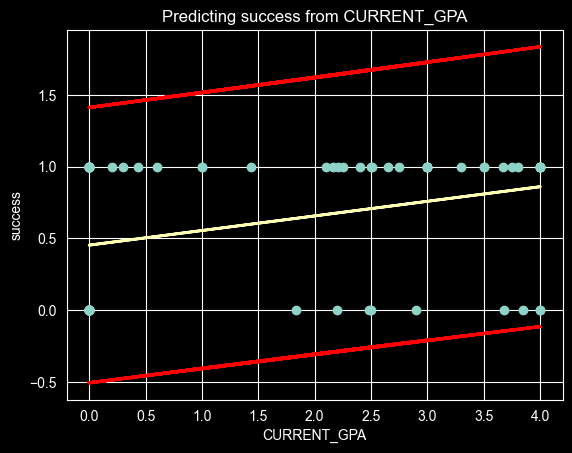

In [82]:
var1= 'CURRENT_GPA'
var2= 'success'
df['CURRENT_GPA'] = df['CURRENT_GPA'].fillna(0)
df['ACT_COMPOSITE_SCORE'] = df['ACT_COMPOSITE_SCORE'].fillna(0)
#split to training and test datasets
import numpy as np
np.random.seed(42)
df['r'] = np.random.uniform(size=len(df))
#df.head()
train=df[df["r"] <= .6]
#train.head()
test=df[df["r"] > .6]
#test.head()
train=train.drop("r",axis=1)
test=test.drop("r",axis=1)

#regression on training data
import statsmodels.api as sm
import matplotlib.pyplot as plt
y=train[var2]
x=train[var1]
x = sm.add_constant(x) #needed to force an intercept into the model
reg = sm.OLS(y,x).fit()
print(reg.summary())

#mean of absolute error (MAE) for test data
tx=test[var1]
tx=sm.add_constant(tx)
psales=reg.predict(tx)
tsales=test[var2]
ae=abs(tsales-psales)
mae=np.mean(ae)
print("The mean absolute error is",mae)

#Root Mean Square Error of test predictions
N=len(test)
rmse=np.sqrt((np.sum((tsales-psales)**2))/N)
print("The root mean square error is",rmse)

#Prediction interval plot
#-------------------
#remove the intercept for the scatterplot
x=train[var1]
#import another regression module
from statsmodels.stats.outliers_influence import summary_table
#create a table of regression information from our regression problem
st, data, ss2 = summary_table(reg, alpha=0.05)
#extract the predicted values to create the regression line on the graph
fittedvalues = data[:, 2]
#extract the confidence intervals for an individual value (prediction intervals)
predict_ci_low, predict_ci_upp = data[:, 6:8].T
fig=plt.figure()
ax=fig.add_subplot(1,1,1)
temp=ax.plot(x, y, 'o')
temp=ax.plot(x, fittedvalues, '-', lw=2)
temp=ax.plot(x, predict_ci_low, 'r--', lw=2)
temp=ax.plot(x, predict_ci_upp, 'r--', lw=2)
temp=ax.set_title(f"Predicting {var2} from {var1}")
temp=ax.set_xlabel(var1)
temp=ax.set_ylabel(var2)
